# PyTorch Codebase Knowledge Graph

This notebook demonstrates how to visualize and explore the PyTorch codebase knowledge graph.

PYTORCH CODEBASE KNOWLEDGE GRAPH

Graph Statistics:
  Nodes: 206
  Edges: 115

Node Types:
  module: 90
  other: 78
  class: 25
  function: 13

Edge Types:
  imports: 57
  calls: 35
  inherits: 23

Connected Components Analysis:
  Largest component: 40 nodes
  Total components: 116
Showing top components: 100 nodes


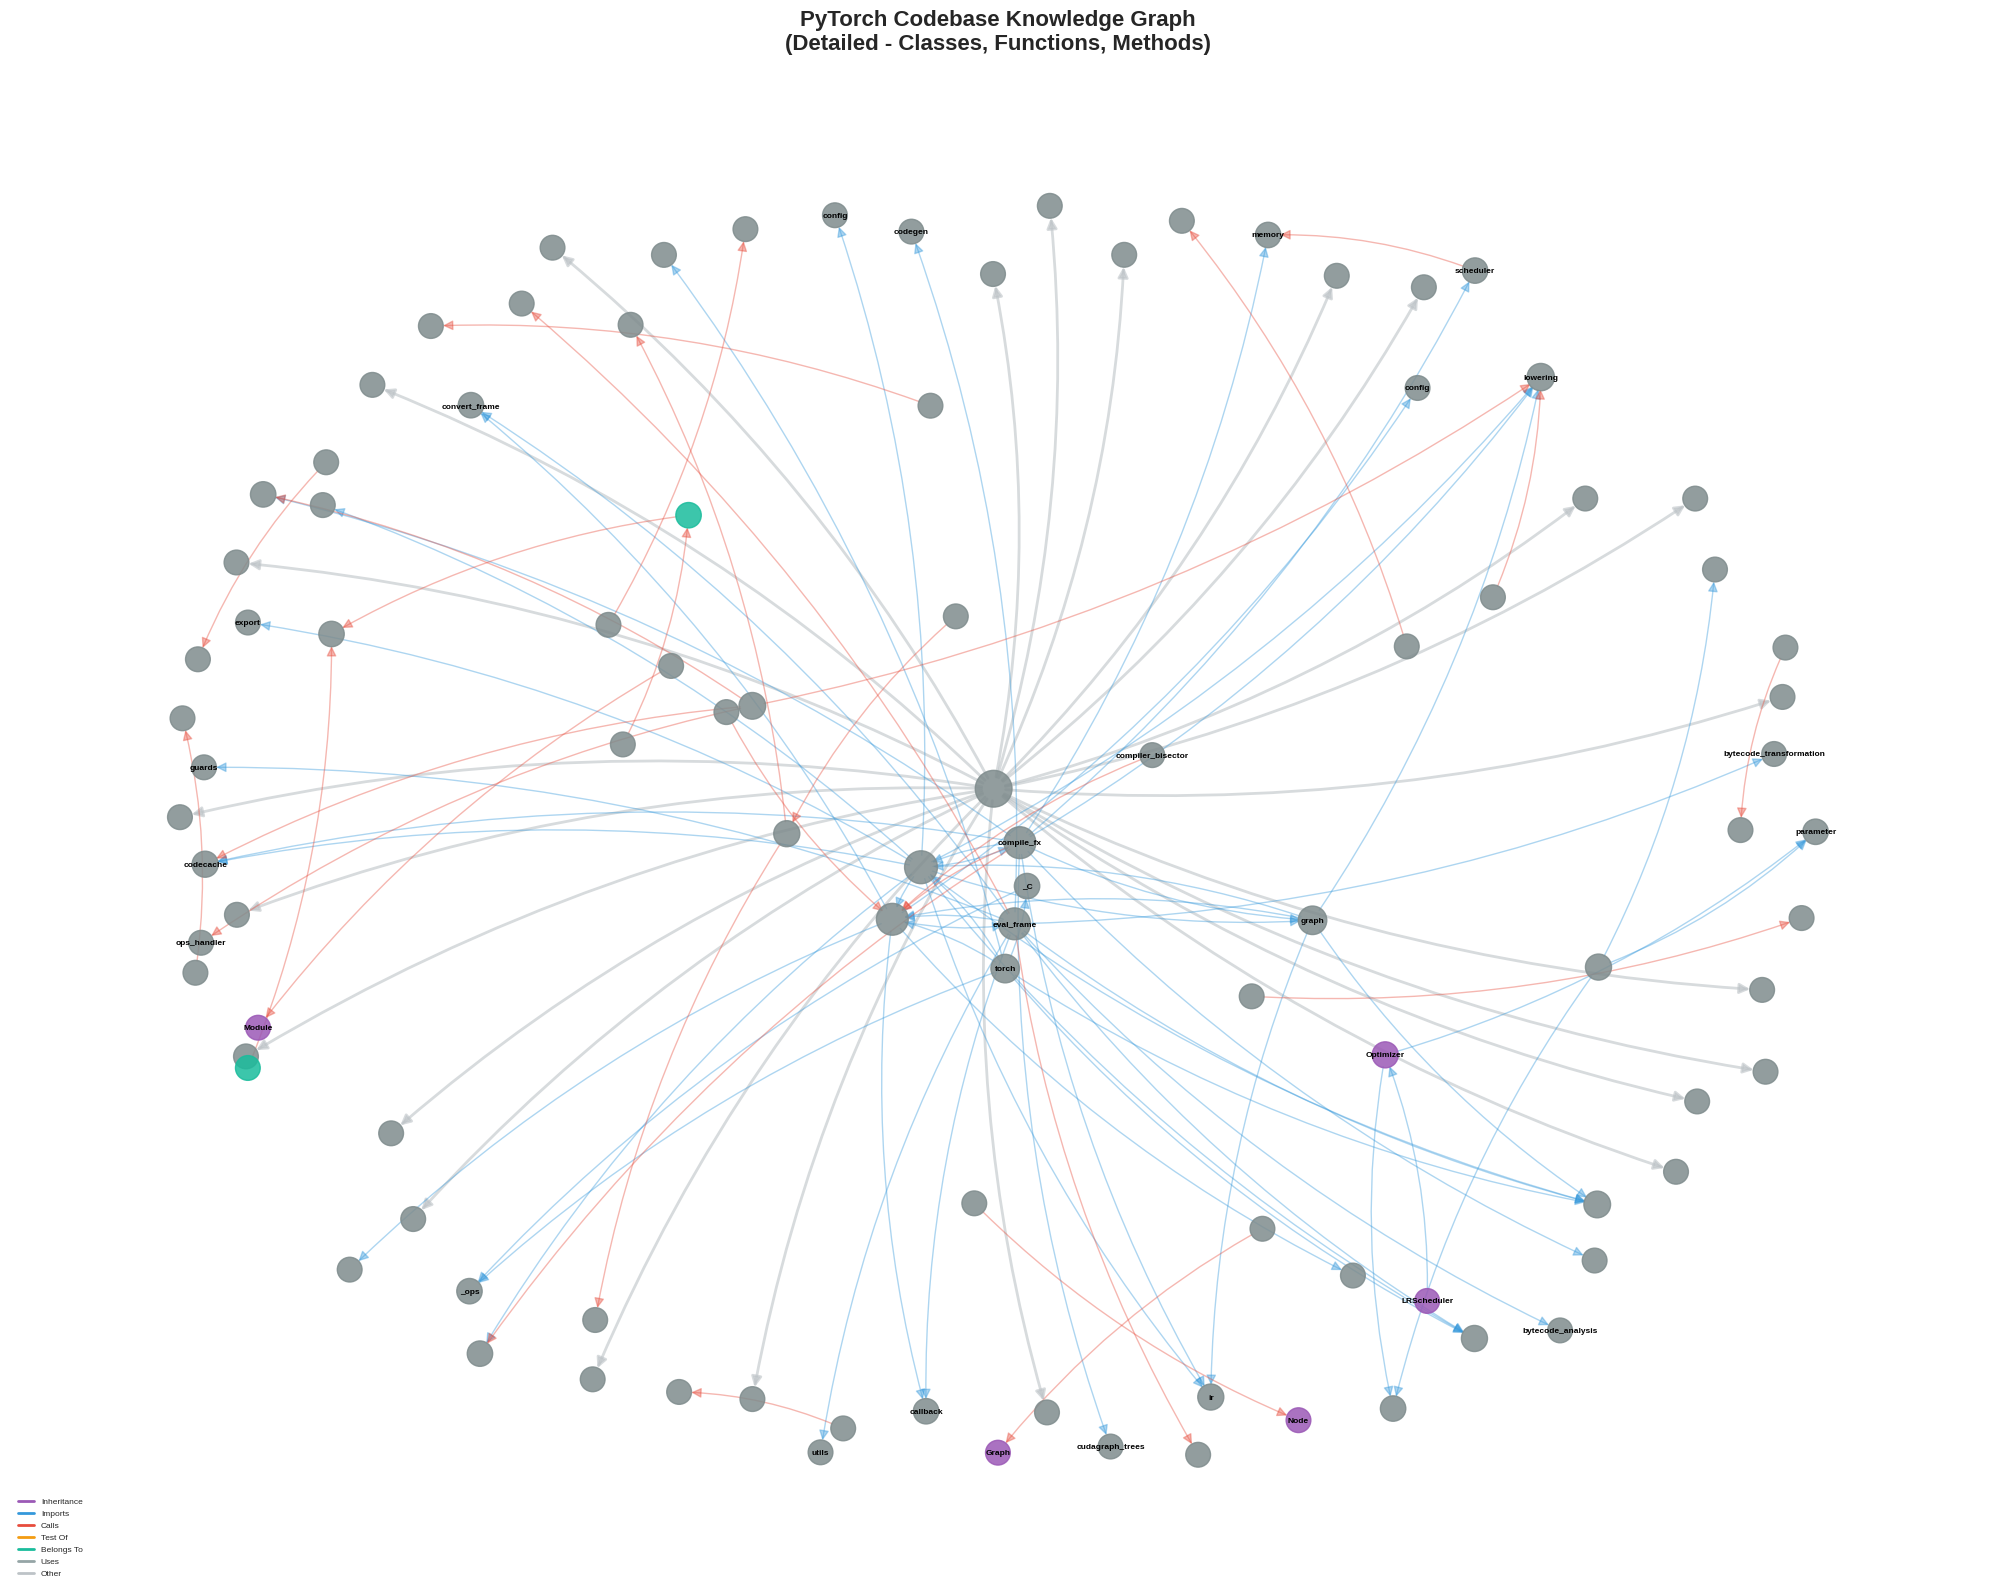


INTERACTIVE GRAPH EXPLORATION

1. Most Connected Nodes (Top 15):
   Node ID (Name) - Connections
   torch.nn.modules.module.Module - 23
   torch._inductor                - 15
   eval_frame                     - 13
   compile_fx                     - 13
   torch._dynamo                  - 13
   torch                          - 7
   graph                          - 7
   lowering                       - 5
   torch._inductor.graph.lower    - 4
   torch.fx                       - 4
   torch.nn                       - 3
   codecache                      - 3
   torch.autograd                 - 3
   Optimizer                      - 3
   ir                             - 3

2. Classes by Module:

   fx:
     - Node
     - Graph

   modules:
     - Module

   optim:
     - Optimizer
     - LRScheduler

3. Key Subsystems:

   TorchInductor (0 components):

   TorchDynamo (0 components):

   TorchFX (1 components):
     - compile_fx

   torch.nn Classes (1):
     - Module

4. Key Inheritance Chain

In [13]:
# Run the visualization script
%run visualize_knowledge_graph.py

PYTORCH CODEBASE KNOWLEDGE GRAPH

Graph Statistics:
  Nodes: 206
  Edges: 115

Node Types:
  module: 90
  other: 78
  class: 25
  function: 13

Edge Types:
  imports: 57
  calls: 35
  inherits: 23

Largest Connected Component: 40 nodes
Showing top 200 nodes from largest component


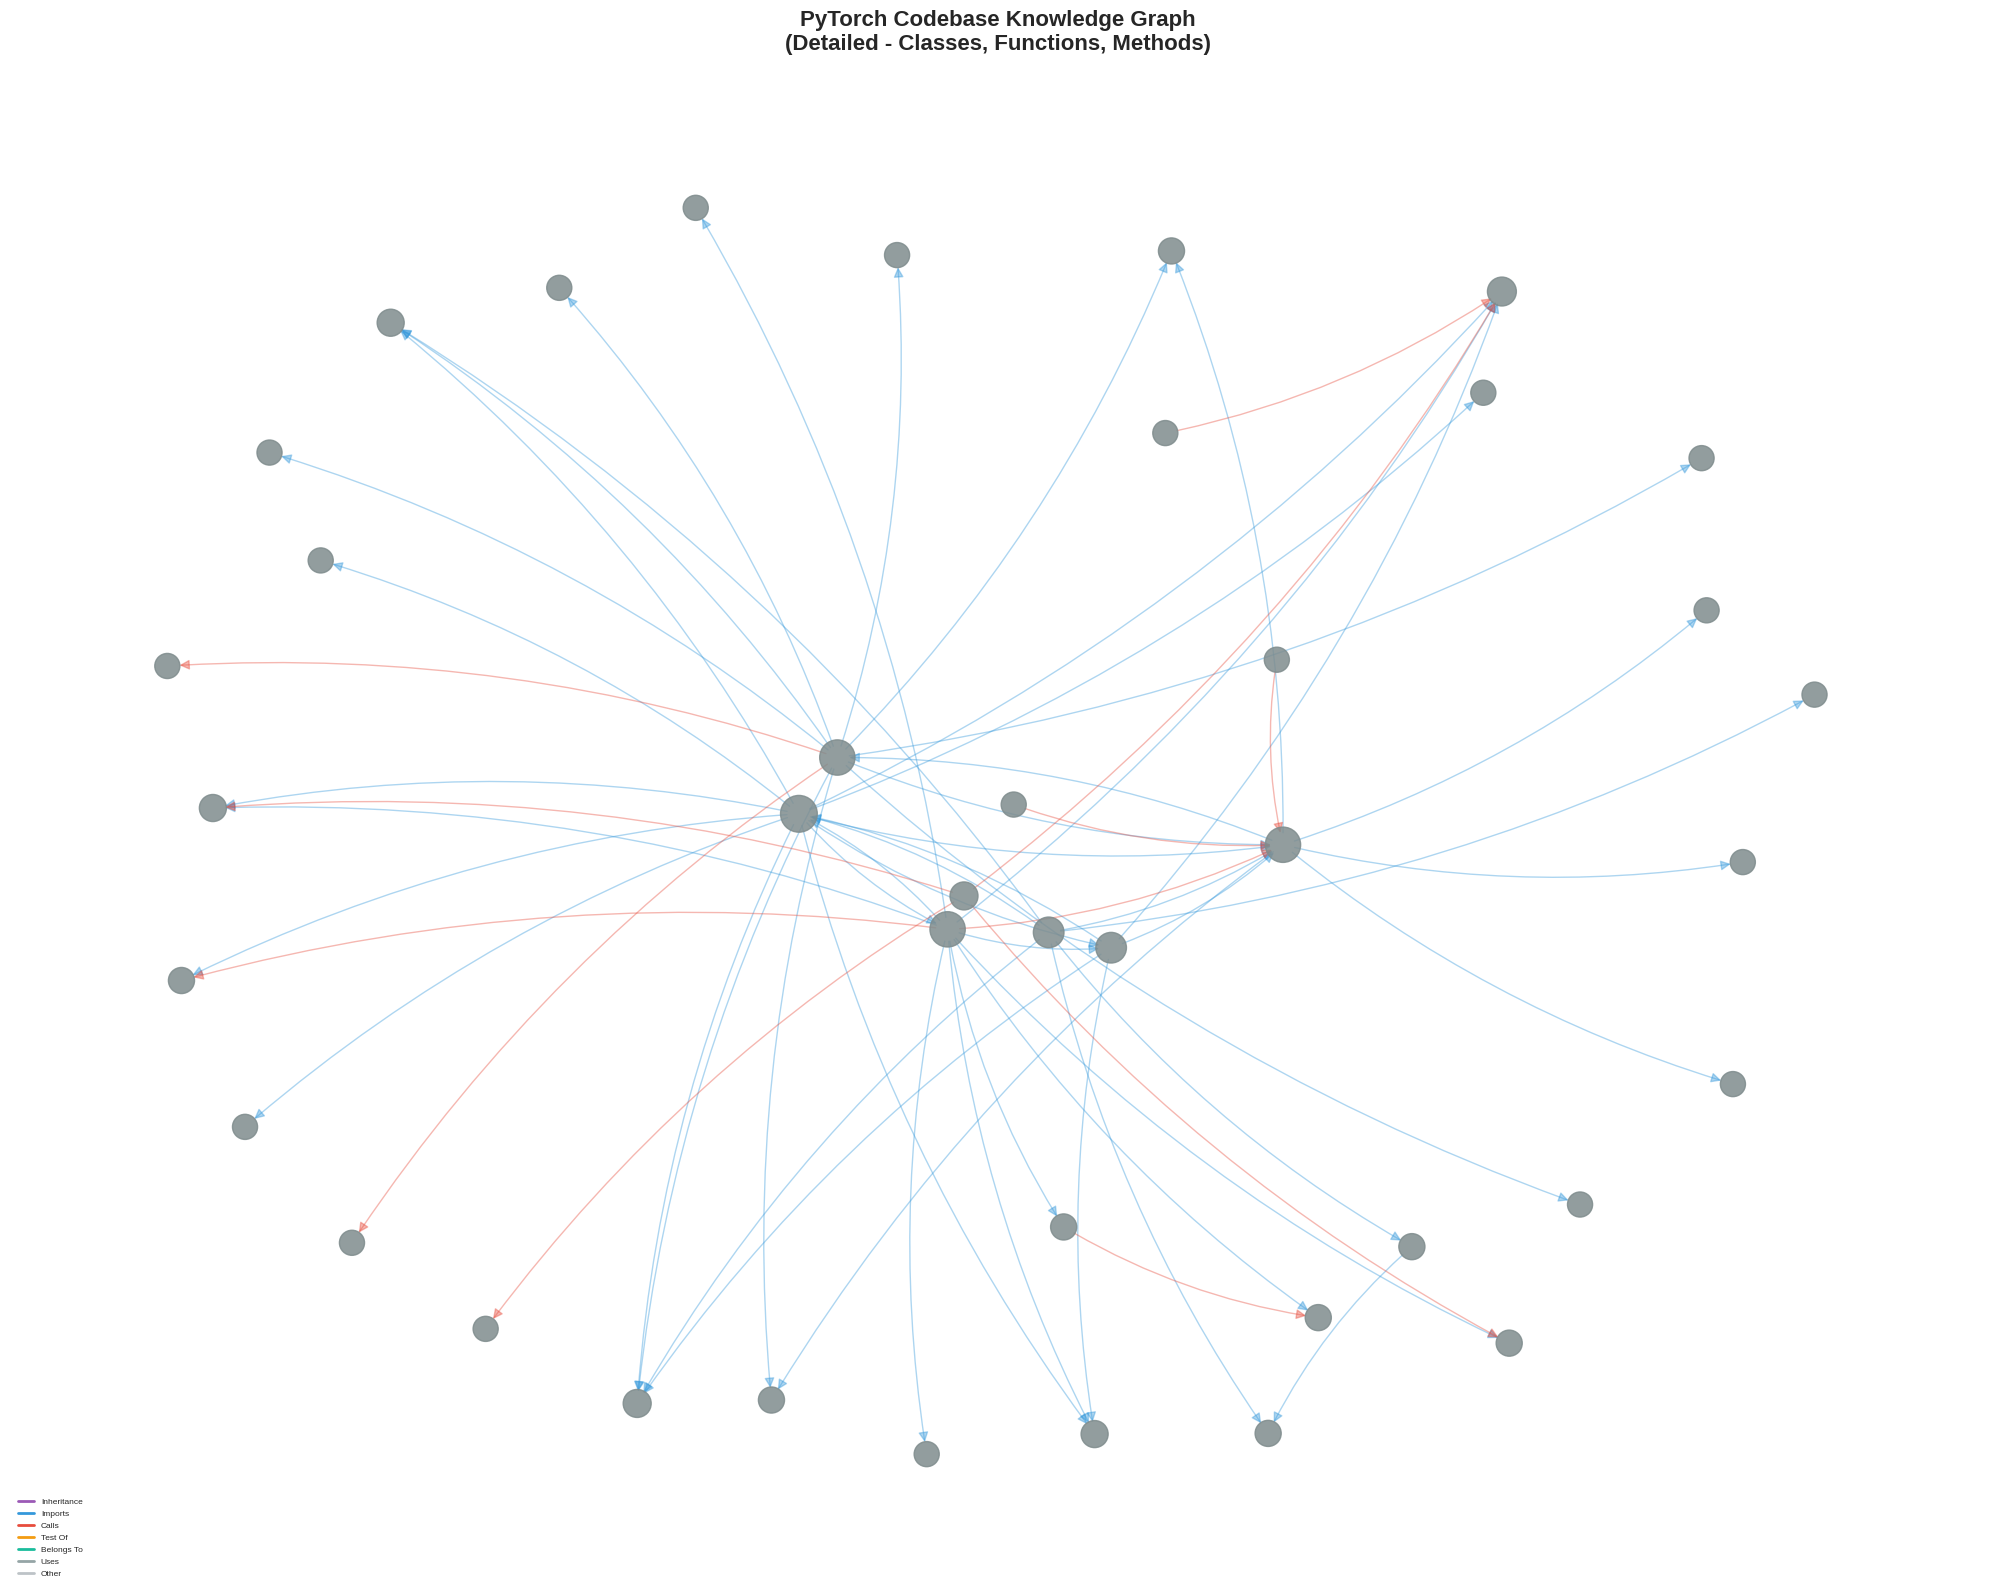

In [14]:
# Load and visualize the knowledge graph
from visualize_knowledge_graph import visualize_pytorch_knowledge_graph

G, pos = visualize_pytorch_knowledge_graph(max_nodes=200)

## Graph Statistics

In [5]:
print(f"Total Nodes: {G.number_of_nodes()}")
print(f"Total Edges: {G.number_of_edges()}")
print("\nNode Types:")
from collections import Counter
node_type_counts = Counter(node_data.get('type', 'other') for _, node_data in G.nodes(data=True))
for node_type, count in sorted(node_type_counts.items(), key=lambda x: -x[1]):
    print(f"  {node_type}: {count}")

print("\nEdge Types:")
edge_type_counts = Counter(data.get('link_type', 'other') for _, _, data in G.edges(data=True))
for edge_type, count in sorted(edge_type_counts.items(), key=lambda x: -x[1]):
    print(f"  {edge_type}: {count}")

Total Nodes: 40
Total Edges: 63

Node Types:
  module: 26
  other: 14

Edge Types:
  imports: 51
  calls: 12


## Interactive Analysis

In [6]:
# Degree of each node
degrees = dict(G.degree())
sorted_nodes = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:10]
print("Most connected nodes (Top 10):")
for node_id, degree in sorted_nodes:
    name = G.nodes[node_id].get('name', node_id)
    print(f"  {name}: {degree} connections")

Most connected nodes (Top 10):
  torch._inductor: 15 connections
  torch._dynamo: 13 connections
  compile_fx: 13 connections
  eval_frame: 13 connections
  torch: 7 connections
  graph: 7 connections
  lowering: 5 connections
  torch._inductor.graph.lower: 4 connections
  torch.fx: 4 connections
  torch.autograd: 3 connections


In [7]:
# Find nodes connected to key components
print("\nNodes connected to Module:")
module_nodes = list(G.neighbors('torch.nn.modules.module.Module'))
print(f"  {len(module_nodes)} connections")
for node in module_nodes[:5]:
    print(f"  - {G.nodes[node].get('name', node)}")


Nodes connected to Module:


NetworkXError: The node torch.nn.modules.module.Module is not in the digraph.

In [8]:
# Explore the knowledge graph subsystems
print("\n=== Key Subsystems ===")

# Inductor components
inductor_nodes = [n for n, d in G.nodes(data=True)
                 if 'inductor' in d.get('name', '').lower()]
print(f"\nTorchInductor ({len(inductor_nodes)} components):")
for node in sorted(inductor_nodes, key=lambda x: G.nodes[x].get('name', ''))[:10]:
    print(f"  - {G.nodes[node].get('name', node)}")

# Dynamo components
dynamo_nodes = [n for n, d in G.nodes(data=True)
               if 'dynamo' in d.get('name', '').lower()]
print(f"\nTorchDynamo ({len(dynamo_nodes)} components):")
for node in sorted(dynamo_nodes, key=lambda x: G.nodes[x].get('name', ''))[:10]:
    print(f"  - {G.nodes[node].get('name', node)}")

# FX components
fx_nodes = [n for n, d in G.nodes(data=True)
           if 'fx' in d.get('name', '').lower()]
print(f"\nTorchFX ({len(fx_nodes)} components):")
for node in sorted(fx_nodes, key=lambda x: G.nodes[x].get('name', ''))[:10]:
    print(f"  - {G.nodes[node].get('name', node)}")


=== Key Subsystems ===

TorchInductor (0 components):

TorchDynamo (0 components):

TorchFX (1 components):
  - compile_fx


In [9]:
# Interactive exploration
from visualize_knowledge_graph import explore_graph

# Use explore_graph if you want detailed output
# explore_graph(G)  # Uncomment to see detailed exploration output

print("\nGraph exploration completed!")
print(f"\nKey insights:")
print("- Most connected node: {0} with {1} connections".format(
    G.nodes[sorted_nodes[0][0]].get('name', sorted_nodes[0][0]),
    sorted_nodes[0][1]))


Graph exploration completed!

Key insights:
- Most connected node: torch._inductor with 15 connections


In [12]:
G['']

NodeView(('torch._dynamo', 'torch._C._autograd', 'torch._C._autograd._saved_tensors_hooks_set_tracing', 'torch._inductor.compile_fx.compile_fx', 'torch._C._inductor', 'torch.autograd', 'torch._C._dynamo', 'torch._inductor.ops_handler', 'torch._inductor.scheduler', 'torch._inductor.memory', 'torch', 'torch._inductor.graph.lower', 'torch._dynamo.callback', 'torch._inductor.codecache', 'torch._ops', 'torch._dynamo.bytecode_transformation', 'torch._inductor.cudagraph_trees', 'torch._dynamo.codegen', 'torch.fx', 'torch._dynamo.config', 'torch._inductor.compile_fx.compile_fx_aot', 'torch._dynamo.guards', 'torch._dynamo.bytecode_analysis', 'torch._inductor.compile_fx', 'torch._inductor.ir', 'torch.optim', 'torch._inductor.lowering', 'torch._inductor.graph', 'torch.export', 'torch._dynamo.compiled_autograd', 'torch._dynamo.convert_frame', 'torch._C', 'torch._inductor.config', 'torch._dynamo.utils', 'torch._inductor.compiler_bisector', 'torch._dynamo.eval_frame', 'torch._C._dynamo.eval_frame.se